# TE Northeast Neighbor Analysis

Why do nearby basins have different dominant forcings and peak lags, especially in the Northeast?

---

## Background

In my earlier work, I computed Transfer Entropy (TE) from four atmospheric forcings — PRCP, SRAD, Tair, and VP — to streamflow Q for all 671 CAMELS basins. I used lags from 1 to 30 days. For each basin, I found two things:

- the dominant forcing — which forcing had the highest TE value, and
- the peak lag — at which lag that highest TE occurred.

When I mapped these across the U.S., I noticed something interesting in the Northeast. Nearby basins often had very different dominant forcings. For example, one basin would be PRCP-dominant, and another basin just 100 km away would be Tair-dominant or SRAD-dominant. Also, some basins peaked at very long lags (20 to 30 days) while their neighbors peaked within just a few days.

This raised a question — if two basins are geographically close, they should have similar climate. So why do their TE results look so different? My advisor suggested I look into this more carefully.

---

## Aim

To understand why nearby basins in the Northeast show different dominant forcings and peak lags, and to check whether these differences are real or whether they come from unstable labels.

---

## What I plan to do

1. For each basin, compute two simple numbers to check how reliable the dominant forcing and peak lag labels are:
   - how much the top forcing wins over the second-best forcing, and
   - whether the TE peak is sharp or just a flat curve across many lags.

2. Check whether Northeast basins look more unstable than basins in other parts of the country.

3. Re-draw the dominant forcing and peak lag maps using only the basins where the labels are reliable, and see if the Northeast pattern changes.

4. Compare CAMELS basin attributes (climate, soil, geology, topography, vegetation, snow) between reliable and unreliable basins to find what makes a basin's label unstable.

5. Do the same comparison but only within the Northeast to see if the same attributes explain the pattern regionally.

6. Look at the two long-lag Tair basins from my earlier work and check if they fit the pattern found here.

---

## Scope

- I compute everything for all 671 CAMELS basins so the Northeast can be compared against the rest of the country.
- For regional focus, I use HUC 02 regions 01 (New England), 02 (Mid-Atlantic), and 05 (Ohio). These cover both the mixed forcing pattern and the long-lag basins I saw in the maps.
- All inputs (TE results, shuffle test results, CAMELS attributes) come from my earlier project folders.

---

## Notes

- TE measures lagged information transfer between two variables. It does not prove direct physical causation. Basin-to-basin differences in TE can also come from seasonal cycles, shared climate patterns, or storage effects.
- The "dominant forcing" label is just whichever forcing had the highest TE value. If the top few forcings are very close in value, this label can easily flip with small changes in the data. That is a key concern in this notebook.
- Two basins being geographically close does not mean they are similar in elevation, snow, geology, or vegetation. I keep this in mind when comparing neighbor basins.
- I describe findings as "consistent with" or "may suggest" rather than claiming direct causation.

---

## Outputs

All outputs are saved in:

- `outputs/summary_csv` — summary tables (one row per basin, robustness metrics, attribute comparisons)
- `outputs/pdf` — figures (CONUS maps, boxplots)
- `outputs/logs` — log files

## Step 1 — Project setup

In this step I set up the project folder and output subfolders, and load the data I will need:

- TE results for all 671 basins (from earlier work)
- Shuffle-test results
- Basin metadata (gauge id, name, latitude, longitude, HUC region, elevation, slope, area)

I do not compute anything in this step. I only read existing files and check that everything loaded correctly.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

In [2]:
# 1) New project folder
PROJECT_DIR = Path(
    r"C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Research -CAMELS\TE Northeast neighbor analysis"
)

# 2) Make output subfolders
OUT_DIR = PROJECT_DIR / "outputs"
OUT_SUMMARY = OUT_DIR / "summary_csv"
OUT_PDF = OUT_DIR / "pdf"
OUT_LOGS = OUT_DIR / "logs"

for d in [OUT_SUMMARY, OUT_PDF, OUT_LOGS]:
    d.mkdir(parents=True, exist_ok=True)

print("Project folder:", PROJECT_DIR)
print("Output folder :", OUT_DIR)

# 3) Folders where my existing TE results and CAMELS attributes are
TE_SUMMARY_DIR = Path(
    r"C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research\Final research code\ALL CAMELS BASIN (FORCINGS TO STREAMFLOW)\outputs\summary_csv"
)
ATTR_DIR = Path(
    r"C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Python\Jupyter Notebook\CAMELS Research"
)

print("\nTE summary folder exists?  ", TE_SUMMARY_DIR.exists())
print("Attribute folder exists?   ", ATTR_DIR.exists())

# 4) Load TE results (basin x forcing x lag, long format)
te_all = pd.read_csv(TE_SUMMARY_DIR / "TE_AllBasins_tau1_30_PRCPspecial_bins5.csv")
te_all["gauge_id"] = te_all["gauge_id"].astype(str).str.zfill(8)

print("\nTE table shape:", te_all.shape)
print("Expected rows : 671 x 4 x 30 =", 671 * 4 * 30)
print(te_all.head())

# 5) Load shuffle-test results
shuffle_all = pd.read_csv(TE_SUMMARY_DIR / "TE_shuffle_all671_tau1_30_PRCPspecial_bins5.csv")
shuffle_all["gauge_id"] = shuffle_all["gauge_id"].astype(str).str.zfill(8)

# Make sig column a clean True/False
shuffle_all["sig"] = (
    shuffle_all["sig"].astype(str).str.lower()
    .map({"true": True, "false": False})
    .fillna(False)
)

print("\nShuffle table shape:", shuffle_all.shape)
print(shuffle_all.head())

# 6) Load basin metadata: gauge_id, name, lat, lon, huc_02, elevation, slope, area
name_df = pd.read_csv(ATTR_DIR / "camels_name.txt", sep=";", dtype=str)
topo_df = pd.read_csv(ATTR_DIR / "camels_topo.txt", sep=";")

name_df["gauge_id"] = name_df["gauge_id"].astype(str).str.zfill(8)
topo_df["gauge_id"] = topo_df["gauge_id"].astype(str).str.zfill(8)

basin_meta = name_df.merge(
    topo_df[["gauge_id", "gauge_lat", "gauge_lon", "elev_mean", "slope_mean", "area_gages2"]],
    on="gauge_id",
    how="left"
)

print("\nBasin metadata shape:", basin_meta.shape)
print(basin_meta.head())

# 7) Quick check: how many basins are in each HUC region
print("\nNumber of basins in each HUC 02 region:")
print(basin_meta["huc_02"].value_counts().sort_index())

# 8) Northeast count (HUC 01, 02, 05)
ne_basins = basin_meta[basin_meta["huc_02"].isin(["01", "02", "05"])]
print("\nNumber of Northeast basins (HUC 01 + 02 + 05):", len(ne_basins))

Project folder: C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Research -CAMELS\TE Northeast neighbor analysis
Output folder : C:\Users\ppaudel2\OneDrive - The University of Alabama\Desktop\Python\Research -CAMELS\TE Northeast neighbor analysis\outputs

TE summary folder exists?   True
Attribute folder exists?    True

TE table shape: (80520, 7)
Expected rows : 671 x 4 x 30 = 80520
   gauge_id  huc_02 Source Target  Bins  Lag   TE_nats
0  01013500       1   PRCP      Q     5    1  0.002761
1  01013500       1   PRCP      Q     5    2  0.001754
2  01013500       1   PRCP      Q     5    3  0.001439
3  01013500       1   PRCP      Q     5    4  0.000913
4  01013500       1   PRCP      Q     5    5  0.001240

Shuffle table shape: (80520, 10)
   gauge_id  huc_02 Source Target  Bins  Lag    TE_obs     thr95      pval  \
0  01013500       1   PRCP      Q     5    1  0.002761  0.001187  0.004975   
1  01013500       1   PRCP      Q     5    2  0.001754  0.001171  0.0049

## Step 2 — Robustness metrics for each basin

In this step, I compute two simple numbers for each basin to check how clear the dominant forcing and peak lag really are.

1. **Forcing margin** = how much the rank-1 forcing beats the rank-2 forcing.
   margin = (rank1_peakTE − rank2_peakTE) / rank1_peakTE
   - Large margin = clear winner.
   - Small margin = top two forcings are nearly tied, so the "dominant forcing" label is not very meaningful.

2. **Lag plateau width** = number of lags where TE is within 90% of the peak TE, for the dominant forcing only.
   - Width = 1 → sharp peak, peak lag is meaningful.
   - Width = many → flat curve, peak lag is just where the argmax happens to fall.

I do not pick thresholds yet. I only compute the numbers and look at the histograms to see what the data looks like.

Saved: basin_robustness_metrics.csv
Shape: (671, 9)
   gauge_id  huc_02 dominant_forcing  dominant_lag  rank1_TE rank2_forcing  \
0  01013500       1             Tair            14  0.004888          SRAD   
1  01022500       1             PRCP             1  0.016681          Tair   
2  01030500       1             PRCP             1  0.013428          Tair   
3  01031500       1             PRCP             1  0.003859            VP   
4  01047000       1             PRCP             1  0.002277          Tair   

   rank2_TE    margin  plateau_width  
0  0.003063  0.373294              2  
1  0.008300  0.502402              1  
2  0.007460  0.444399              1  
3  0.001597  0.586076              1  
4  0.001541  0.323167              1  

Margin: how clearly the rank-1 forcing wins (0 = tied, 1 = rank-2 is zero)
count    671.000
mean       0.283
std        0.200
min        0.002
25%        0.105
50%        0.247
75%        0.444
max        0.766
Name: margin, dtype: float64

Pla

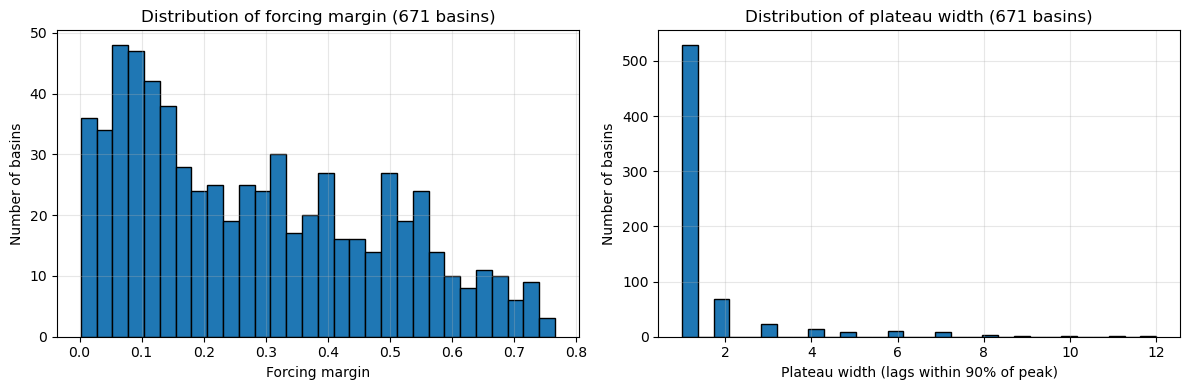


Saved figure: robustness_histograms.png


In [3]:
# Step 2: compute forcing margin and lag plateau width per basin

# 1) Peak TE and peak lag for every basin x forcing
idx = te_all.groupby(["gauge_id", "Source"])["TE_nats"].idxmax()
peak_per_forcing = te_all.loc[idx, ["gauge_id", "huc_02", "Source", "Lag", "TE_nats"]]
peak_per_forcing = peak_per_forcing.rename(columns={"Lag": "peak_lag", "TE_nats": "peak_TE"})

# 2) For each basin, sort the four peak TE values from largest to smallest
peak_sorted = peak_per_forcing.sort_values(
    ["gauge_id", "peak_TE"], ascending=[True, False]
)

# rank within basin: 1 = largest, 4 = smallest
peak_sorted["rank"] = peak_sorted.groupby("gauge_id")["peak_TE"].rank(
    method="first", ascending=False
).astype(int)

# 3) Pick rank-1 (winner) and rank-2 (runner-up) for each basin
rank1 = peak_sorted[peak_sorted["rank"] == 1][["gauge_id", "huc_02", "Source", "peak_lag", "peak_TE"]]
rank1 = rank1.rename(columns={
    "Source": "dominant_forcing",
    "peak_TE": "rank1_TE",
    "peak_lag": "dominant_lag"
})

rank2 = peak_sorted[peak_sorted["rank"] == 2][["gauge_id", "Source", "peak_TE"]]
rank2 = rank2.rename(columns={
    "Source": "rank2_forcing",
    "peak_TE": "rank2_TE"
})

# 4) Compute the forcing margin
robust = rank1.merge(rank2, on="gauge_id")
robust["margin"] = (robust["rank1_TE"] - robust["rank2_TE"]) / robust["rank1_TE"]

# 5) Compute the lag plateau width for the dominant forcing
plateau_widths = []

for _, row in robust.iterrows():
    gid = row["gauge_id"]
    dom = row["dominant_forcing"]
    
    # TE curve for this basin and dominant forcing across lags 1..30
    curve = te_all[(te_all["gauge_id"] == gid) & (te_all["Source"] == dom)]
    te_values = curve["TE_nats"].values
    
    if len(te_values) == 0 or np.all(np.isnan(te_values)):
        plateau_widths.append(np.nan)
        continue
    
    peak_val = np.nanmax(te_values)
    threshold = 0.9 * peak_val
    width = int(np.sum(te_values >= threshold))
    plateau_widths.append(width)

robust["plateau_width"] = plateau_widths

# 6) Save the result
out_file = OUT_SUMMARY / "basin_robustness_metrics.csv"
robust.to_csv(out_file, index=False)

print("Saved:", out_file.name)
print("Shape:", robust.shape)
print(robust.head())

# 7) Quick summary statistics
print("\nMargin: how clearly the rank-1 forcing wins (0 = tied, 1 = rank-2 is zero)")
print(robust["margin"].describe().round(3))

print("\nPlateau width: how many lags out of 30 are within 90% of peak TE")
print(robust["plateau_width"].describe().round(2))

# 8) Plot the two histograms
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(robust["margin"].dropna(), bins=30, edgecolor="black")
axes[0].set_xlabel("Forcing margin")
axes[0].set_ylabel("Number of basins")
axes[0].set_title("Distribution of forcing margin (671 basins)")
axes[0].grid(True, alpha=0.3)

axes[1].hist(robust["plateau_width"].dropna(), bins=30, edgecolor="black")
axes[1].set_xlabel("Plateau width (lags within 90% of peak)")
axes[1].set_ylabel("Number of basins")
axes[1].set_title("Distribution of plateau width (671 basins)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

# Save the figure
fig_file = OUT_PDF / "robustness_histograms.png"
plt.savefig(fig_file, dpi=200, bbox_inches="tight")
plt.show()

print("\nSaved figure:", fig_file.name)

### What I found

Looking at the forcing margin first — the typical basin's top forcing beats the second-best forcing by only about 25%. That is not a large gap. About one in four basins has an even smaller margin, where the top two forcings are so close that the dominant forcing label could easily change with slightly different data. So for many basins, calling one forcing "dominant" is not very reliable.

The plateau width is less of a problem. For almost all basins, the peak lag is sharp — meaning only one or two lags stand out at the top. So the peak lag values are generally trustworthy.

The bigger concern here is the margin, not the plateau width. This already hints at something important — part of the reason nearby Northeast basins appear to have different dominant forcings might simply be because their top forcings are nearly tied, and small differences in the data push the label one way or the other.


## Step 3 — Apply robustness thresholds

Now I apply the thresholds to separate robust basins from fragile ones.

A basin is called **robust** if both:
- margin ≥ 0.20 (rank-1 forcing clearly beats rank-2), and
- plateau width ≤ 3 (peak lag is sharp).

Otherwise it is called **fragile**.

I count how many basins pass the test in each HUC region, with focus on the Northeast (HUC 01, 02, 05).

In [4]:
# Step 3: apply robustness thresholds and count pass/fail per region

# 1) Thresholds
MARGIN_MIN = 0.20
PLATEAU_MAX = 3

# 2) Add robust flag to the table
robust["is_robust"] = (
    (robust["margin"] >= MARGIN_MIN) &
    (robust["plateau_width"] <= PLATEAU_MAX)
)

# 3) Overall pass rate
n_total = len(robust)
n_robust = int(robust["is_robust"].sum())
n_fragile = n_total - n_robust

print("Thresholds: margin >=", MARGIN_MIN, "and plateau_width <=", PLATEAU_MAX)
print()
print("Total basins :", n_total)
print("Robust       :", n_robust, "(", round(100*n_robust/n_total, 1), "% )")
print("Fragile      :", n_fragile, "(", round(100*n_fragile/n_total, 1), "% )")

# 4) Pass rate per HUC region
print("\nPass rate per HUC 02 region:")
huc_summary = (
    robust.groupby("huc_02")["is_robust"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "n_robust", "count": "n_total"})
)
huc_summary["pct_robust"] = (100 * huc_summary["n_robust"] / huc_summary["n_total"]).round(1)
print(huc_summary)

# 5) Northeast vs rest of CONUS
ne_hucs = ["01", "02", "05"]
robust["region"] = np.where(robust["huc_02"].astype(str).str.zfill(2).isin(ne_hucs),
                            "Northeast", "Rest of CONUS")

print("\nNortheast vs rest of CONUS:")
region_summary = (
    robust.groupby("region")["is_robust"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "n_robust", "count": "n_total"})
)
region_summary["pct_robust"] = (100 * region_summary["n_robust"] / region_summary["n_total"]).round(1)
print(region_summary)

# 6) Pass rate per dominant forcing
print("\nPass rate per dominant forcing:")
dom_summary = (
    robust.groupby("dominant_forcing")["is_robust"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "n_robust", "count": "n_total"})
)
dom_summary["pct_robust"] = (100 * dom_summary["n_robust"] / dom_summary["n_total"]).round(1)
print(dom_summary)

# 7) Save updated table
out_file = OUT_SUMMARY / "basin_robustness_metrics.csv"
robust.to_csv(out_file, index=False)
print("\nSaved updated table:", out_file.name)

Thresholds: margin >= 0.2 and plateau_width <= 3

Total basins : 671
Robust       : 370 ( 55.1 % )
Fragile      : 301 ( 44.9 % )

Pass rate per HUC 02 region:
        n_robust  n_total  pct_robust
huc_02                               
1             12       27        44.4
2             17       75        22.7
3             62       92        67.4
4             17       31        54.8
5             16       45        35.6
6              6       17        35.3
7             26       33        78.8
8              7       12        58.3
9              4        9        44.4
10            38       70        54.3
11            24       31        77.4
12            20       37        54.1
13             5        7        71.4
14             6       17        35.3
15            10       19        52.6
16            11       18        61.1
17            64       91        70.3
18            25       40        62.5

Northeast vs rest of CONUS:
               n_robust  n_total  pct_robust
region 

### What I found

Only about 55% of all 671 basins passed the robustness check. This means for almost half of CAMELS basins, either the top forcings are too close to each other, or the TE curve is too flat to trust the dominant forcing or peak lag label.

The Northeast stands out clearly here:
- Northeast (HUC 01, 02, 05): 45 of 147 basins are robust (30.6%)
- Rest of CONUS: 325 of 524 basins are robust (62.0%)

So the Northeast has roughly half the pass rate of everywhere else. This is the most important result from this step.

This tells me that the mixed forcing pattern I saw in the Northeast maps — where nearby basins seem to have very different dominant forcings — is likely because most Northeast basins do not really have one clearly dominant forcing. All four forcings carry similar TE values, so whichever one comes out slightly on top gets the label, even if the difference is tiny.

Looking at how each forcing group performs:
- PRCP-dominant: 78.9% robust → labels are generally trustworthy
- SRAD-dominant: 36.9% robust → mixed reliability
- Tair-dominant: 4.2% robust → almost never trustworthy
- VP-dominant: 6.5% robust → almost never trustworthy

So when a basin is labeled Tair- or VP-dominant on the original map, that label is almost always unreliable. These are not basins where Tair or VP truly dominates — they are basins where PRCP nearly won but just barely lost to another forcing.

## Step 4 — Side-by-side CONUS maps

I now compare the original maps (all 671 basins) with the robust-only maps (370 basins). The same colors are used for both, so the visual difference shows the effect of removing fragile basins.

If the Northeast mosaic in the dominant-forcing map mostly disappears after filtering, it means the mosaic was largely a labeling artifact. If the mosaic survives, the differences between nearby basins are real and need a hydrologic explanation.

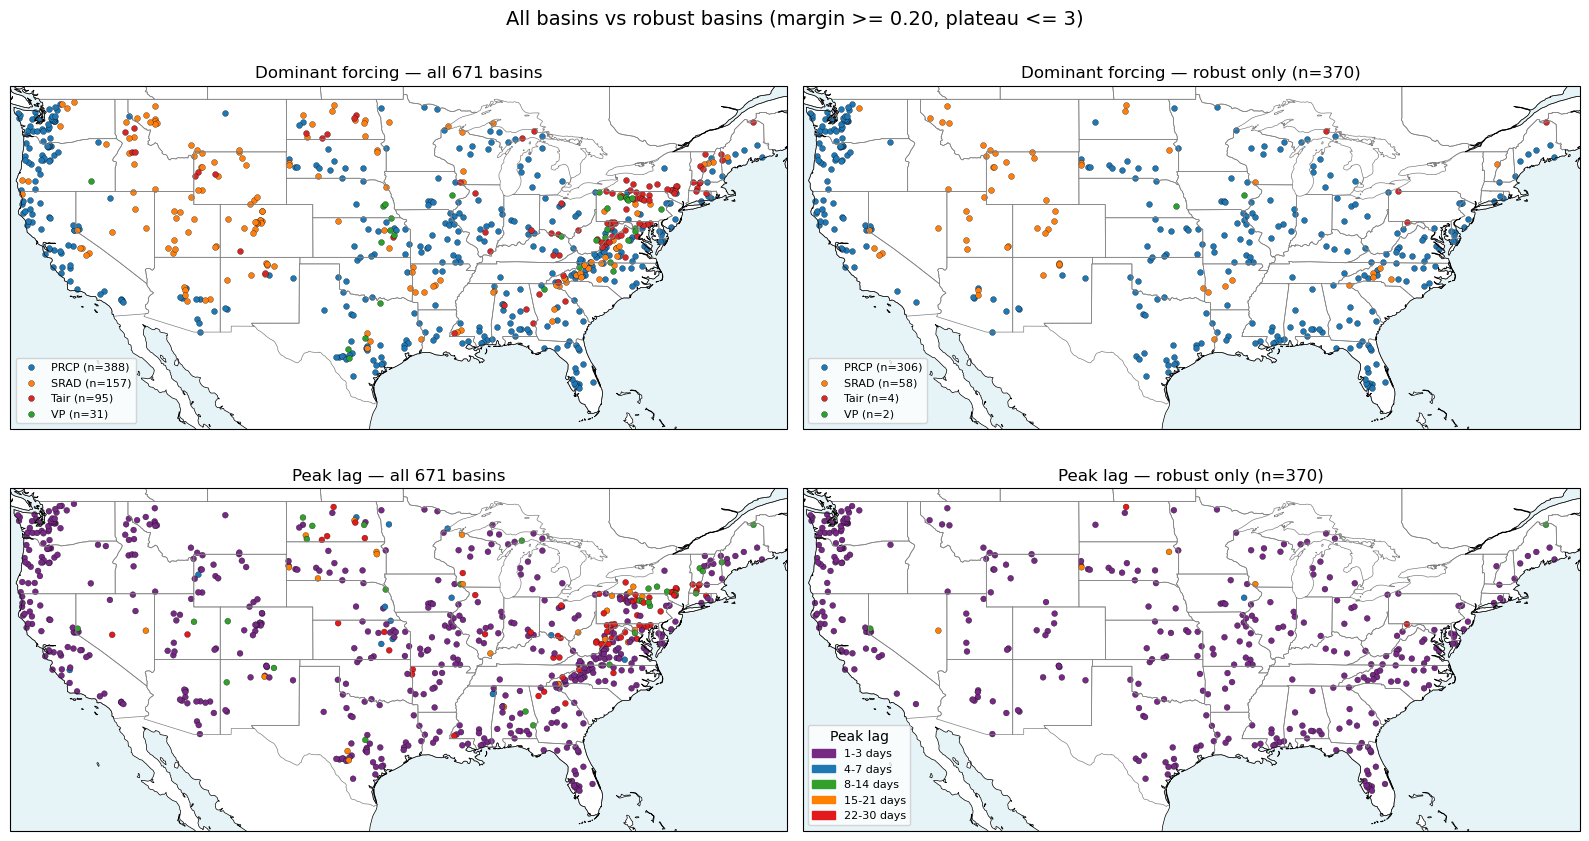

Saved: conus_maps_all_vs_robust.png

Northeast basin counts (HUC 01 + 02 + 05):
  All basins  : 147
  Robust only : 45

Dominant forcing counts in Northeast:
All basins:
dominant_forcing
Tair    61
PRCP    57
SRAD    15
VP      14
Name: count, dtype: int64

Robust only:
dominant_forcing
PRCP    41
Tair     3
SRAD     1
Name: count, dtype: int64


In [14]:
# Step 4: side-by-side CONUS maps, all basins vs robust only

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors

# 1) Add lat / lon to the robust table
robust_map = robust.merge(
    basin_meta[["gauge_id", "gauge_lat", "gauge_lon"]],
    on="gauge_id",
    how="left"
)

# 2) Color settings
forcing_colors = {
    "PRCP": "tab:blue",
    "SRAD": "tab:orange",
    "Tair": "tab:red",
    "VP":   "tab:green",
}
forcing_order = ["PRCP", "SRAD", "Tair", "VP"]

# Discrete color map for peak lag (5 clearly distinct colors)
lag_bins = [0, 3, 7, 14, 21, 31]
lag_labels = ["1-3", "4-7", "8-14", "15-21", "22-30"]
lag_color_list = ["#762a83", "#1f78b4", "#33a02c", "#ff7f00", "#e31a1c"]
lag_cmap = mcolors.ListedColormap(lag_color_list)

def lag_to_color(lag):
    for i, edge in enumerate(lag_bins[1:]):
        if lag <= edge:
            return lag_cmap(i)
    return lag_cmap(len(lag_labels) - 1)

# 3) Set up the 2 x 2 figure with cartopy projection
fig = plt.figure(figsize=(16, 9))
proj = ccrs.PlateCarree()

ax1 = fig.add_subplot(2, 2, 1, projection=proj)
ax2 = fig.add_subplot(2, 2, 2, projection=proj)
ax3 = fig.add_subplot(2, 2, 3, projection=proj)
ax4 = fig.add_subplot(2, 2, 4, projection=proj)

axes = [ax1, ax2, ax3, ax4]

# Add state borders to all four
for ax in axes:
    ax.set_extent([-125, -66, 24, 50], crs=proj)
    ax.add_feature(cfeature.STATES, edgecolor="gray", linewidth=0.5)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.OCEAN, facecolor="lightblue", alpha=0.3)

# 4) Top-left: dominant forcing, all 671 basins
df_all = robust_map
for forcing in forcing_order:
    sub = df_all[df_all["dominant_forcing"] == forcing]
    ax1.scatter(sub["gauge_lon"], sub["gauge_lat"],
                c=forcing_colors[forcing], s=18, edgecolor="black", linewidth=0.2,
                transform=proj, label=f"{forcing} (n={len(sub)})")
ax1.set_title("Dominant forcing — all 671 basins")
ax1.legend(loc="lower left", fontsize=8)

# 5) Top-right: dominant forcing, robust only
df_rob = robust_map[robust_map["is_robust"]]
for forcing in forcing_order:
    sub = df_rob[df_rob["dominant_forcing"] == forcing]
    ax2.scatter(sub["gauge_lon"], sub["gauge_lat"],
                c=forcing_colors[forcing], s=18, edgecolor="black", linewidth=0.2,
                transform=proj, label=f"{forcing} (n={len(sub)})")
ax2.set_title(f"Dominant forcing — robust only (n={len(df_rob)})")
ax2.legend(loc="lower left", fontsize=8)

# 6) Bottom-left: peak lag, all 671 basins
colors_all = [lag_to_color(l) for l in df_all["dominant_lag"]]
ax3.scatter(df_all["gauge_lon"], df_all["gauge_lat"],
            c=colors_all, s=18, edgecolor="black", linewidth=0.2, transform=proj)
ax3.set_title("Peak lag — all 671 basins")

# 7) Bottom-right: peak lag, robust only
colors_rob = [lag_to_color(l) for l in df_rob["dominant_lag"]]
ax4.scatter(df_rob["gauge_lon"], df_rob["gauge_lat"],
            c=colors_rob, s=18, edgecolor="black", linewidth=0.2, transform=proj)
ax4.set_title(f"Peak lag — robust only (n={len(df_rob)})")

# Add a single legend for peak lag in the bottom row
from matplotlib.patches import Patch
lag_legend_handles = [
    Patch(color=lag_cmap(i), label=f"{lag_labels[i]} days")
    for i in range(len(lag_labels))
]
ax4.legend(handles=lag_legend_handles, loc="lower left", fontsize=8, title="Peak lag")

# 8) Save and show
plt.suptitle("All basins vs robust basins (margin >= 0.20, plateau <= 3)", fontsize=14)
plt.tight_layout()

fig_file = OUT_PDF / "conus_maps_all_vs_robust.png"
plt.savefig(fig_file, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", fig_file.name)

# 9) Print a quick count comparison for the Northeast
ne_all = robust_map[robust_map["huc_02"].astype(str).str.zfill(2).isin(["01","02","05"])]
ne_rob = ne_all[ne_all["is_robust"]]

print("\nNortheast basin counts (HUC 01 + 02 + 05):")
print(f"  All basins  : {len(ne_all)}")
print(f"  Robust only : {len(ne_rob)}")
print("\nDominant forcing counts in Northeast:")
print("All basins:")
print(ne_all["dominant_forcing"].value_counts())
print("\nRobust only:")
print(ne_rob["dominant_forcing"].value_counts())

### What I found

The side-by-side maps show a clear pattern.

In the dominant forcing map (top row), the left map shows the original mixed pattern with many Tair- and VP-dominant basins scattered across the Northeast. The right map, after keeping only robust basins, is mostly blue (PRCP). The Northeast mosaic largely disappears.

The Northeast counts confirm this:
- Out of 61 Tair-dominant basins in the Northeast, only 3 are robust.
- Out of 14 VP-dominant basins, none are robust.
- Out of 15 SRAD-dominant basins, only 1 is robust.
- Out of 57 PRCP-dominant basins, 41 are robust.

In the peak lag map (bottom row), the long-lag dots seen in the Northeast in the left map almost completely disappear in the right map. After filtering, almost all robust basins have a peak lag of just 1 to 3 days.

So the Northeast mosaic and the long Tair/VP lags from the original maps are largely a labeling artifact. They show up because Northeast basins have nearly-tied top forcings and flatter TE curves — not because each basin genuinely has a different dominant driver.

This changes the question I am trying to answer. Instead of asking "why do nearby Northeast basins have different dominant forcings?", a better question is: "why do Northeast basins more often have all four forcings carrying similar information about Q, compared to basins in other parts of the country?"

One possible reason is that the Northeast is a wet, vegetated region where PRCP, SRAD, Tair, and VP all vary together with the seasons. So all four forcings end up carrying similar information about Q, and none dominates clearly. In drier regions, water is the main limiting factor, so PRCP stands out much more clearly and the labels are more stable.

In [6]:
# Quick check: which CAMELS attribute files are available
attr_files = [
    "camels_name.txt",
    "camels_clim.txt",
    "camels_geol.txt",
    "camels_hydro.txt",
    "camels_soil.txt",
    "camels_topo.txt",
    "camels_vege.txt",
]

for f in attr_files:
    path = ATTR_DIR / f
    print(f, "->", "exists" if path.exists() else "MISSING")

camels_name.txt -> exists
camels_clim.txt -> exists
camels_geol.txt -> exists
camels_hydro.txt -> exists
camels_soil.txt -> exists
camels_topo.txt -> exists
camels_vege.txt -> exists


## Step 5 — Robust vs fragile attribute comparison (all CONUS)

In this step I compare CAMELS attributes between the 370 robust basins and the 301 fragile basins, using all 671 basins. The goal is to find which basin attributes are most different between the two groups, which will tell me what makes a basin "fragile" (top forcings nearly tied) versus "robust" (one forcing clearly dominant).

For each numeric attribute, I compute:
- mean for robust group
- mean for fragile group
- difference (robust mean − fragile mean)
- a simple effect size to rank attributes by how clearly they separate the two groups

The Northeast-only version of this comparison is done in the next step.

In [7]:
# Step 5: load CAMELS attributes and compare robust vs fragile basins (all CONUS)

# 1) Load all CAMELS attribute files
clim_df  = pd.read_csv(ATTR_DIR / "camels_clim.txt",  sep=";")
geol_df  = pd.read_csv(ATTR_DIR / "camels_geol.txt",  sep=";")
hydro_df = pd.read_csv(ATTR_DIR / "camels_hydro.txt", sep=";")
soil_df  = pd.read_csv(ATTR_DIR / "camels_soil.txt",  sep=";")
topo_df2 = pd.read_csv(ATTR_DIR / "camels_topo.txt",  sep=";")
vege_df  = pd.read_csv(ATTR_DIR / "camels_vege.txt",  sep=";")

# Standardize gauge_id in each
for df in [clim_df, geol_df, hydro_df, soil_df, topo_df2, vege_df]:
    df["gauge_id"] = df["gauge_id"].astype(str).str.zfill(8)

# 2) Merge them all into one big table
attr_all = (
    clim_df
    .merge(geol_df,  on="gauge_id", how="outer")
    .merge(hydro_df, on="gauge_id", how="outer")
    .merge(soil_df,  on="gauge_id", how="outer")
    .merge(topo_df2, on="gauge_id", how="outer")
    .merge(vege_df,  on="gauge_id", how="outer")
)
print("Attribute table shape:", attr_all.shape)
print("Number of columns    :", len(attr_all.columns))

# 3) Merge with the robust labels
data = robust[["gauge_id", "huc_02", "is_robust", "dominant_forcing", "margin"]].merge(
    attr_all, on="gauge_id", how="left"
)
print("Merged table shape:", data.shape)

# 4) Pick only numeric attribute columns (drop ids and category columns)
non_attr_cols = ["gauge_id", "huc_02", "is_robust", "dominant_forcing", "margin"]
attr_cols = [c for c in data.columns if c not in non_attr_cols]
numeric_cols = [c for c in attr_cols if pd.api.types.is_numeric_dtype(data[c])]
print("Number of numeric attributes:", len(numeric_cols))

# 5) For each numeric attribute, compare robust vs fragile groups
rows = []
for col in numeric_cols:
    rob_vals = data.loc[data["is_robust"], col].dropna()
    frg_vals = data.loc[~data["is_robust"], col].dropna()
    
    if len(rob_vals) < 10 or len(frg_vals) < 10:
        continue
    
    mean_rob = rob_vals.mean()
    mean_frg = frg_vals.mean()
    diff = mean_rob - mean_frg
    
    # Simple effect size: difference divided by pooled standard deviation
    pooled_std = np.sqrt((rob_vals.var() + frg_vals.var()) / 2)
    if pooled_std == 0 or np.isnan(pooled_std):
        effect = np.nan
    else:
        effect = diff / pooled_std
    
    rows.append({
        "attribute": col,
        "mean_robust": mean_rob,
        "mean_fragile": mean_frg,
        "diff": diff,
        "effect_size": effect,
        "abs_effect": abs(effect),
        "n_robust": len(rob_vals),
        "n_fragile": len(frg_vals),
    })

attr_compare = pd.DataFrame(rows).sort_values("abs_effect", ascending=False)

# 6) Save the full comparison table
out_file = OUT_SUMMARY / "attr_compare_robust_vs_fragile_CONUS.csv"
attr_compare.to_csv(out_file, index=False)
print("\nSaved:", out_file.name)

# 7) Show the top 15 attributes that separate robust and fragile basins most strongly
print("\nTop 15 attributes that separate robust vs fragile basins (CONUS):")
print(attr_compare[["attribute", "mean_robust", "mean_fragile",
                    "diff", "effect_size"]].head(15).round(3).to_string(index=False))

Attribute table shape: (671, 58)
Number of columns    : 58
Merged table shape: (671, 62)
Number of numeric attributes: 52

Saved: attr_compare_robust_vs_fragile_CONUS.csv

Top 15 attributes that separate robust vs fragile basins (CONUS):
           attribute  mean_robust  mean_fragile   diff  effect_size
soil_depth_pelletier       14.652         6.227  8.425        0.547
            gvf_diff        0.290         0.364 -0.074       -0.513
           gauge_lon      -98.536       -92.414 -6.122       -0.386
   soil_conductivity        1.990         1.434  0.556        0.383
           sand_frac       38.974        33.389  5.585        0.369
   geol_permeability      -13.697       -14.118  0.421        0.361
       high_prec_dur        1.380         1.313  0.067        0.356
           silt_frac       31.797        36.392 -4.595       -0.354
            lai_diff        2.239         2.706 -0.466       -0.351
  soil_depth_statsgo        1.332         1.245  0.087        0.324
              

### Visual check — boxplots of top attributes

Effect size is just one number. To see if the differences are clean separations or messy overlaps, I make boxplots for the top 6 attributes, comparing robust and fragile basins side by side.

Plotting top 6: ['soil_depth_pelletier', 'gvf_diff', 'gauge_lon', 'soil_conductivity', 'sand_frac', 'geol_permeability']


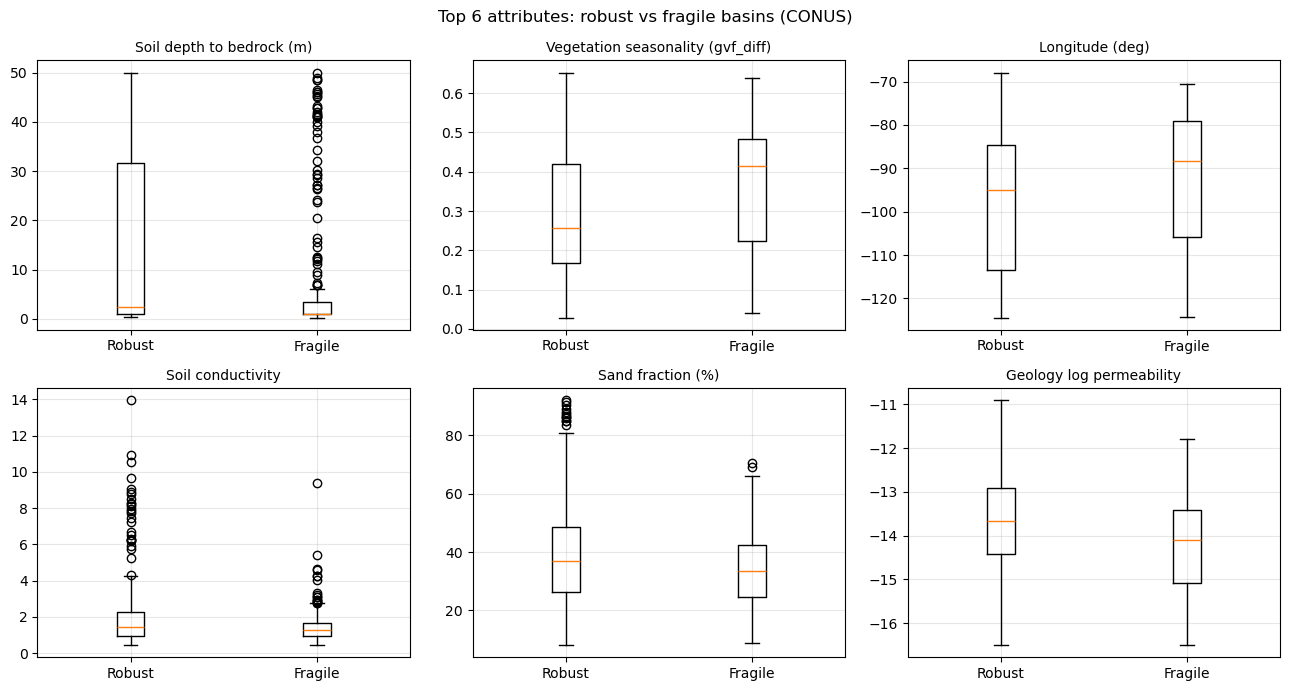

Saved: robust_vs_fragile_boxplots_CONUS.png


In [8]:
# Step 5b: boxplots for top attributes that separate robust vs fragile

# Pick top 6 attributes by absolute effect size
top_attrs = attr_compare.head(6)["attribute"].tolist()
print("Plotting top 6:", top_attrs)

# Plain English labels for the plots
attr_labels = {
    "soil_depth_pelletier": "Soil depth to bedrock (m)",
    "gvf_diff":             "Vegetation seasonality (gvf_diff)",
    "gauge_lon":            "Longitude (deg)",
    "soil_conductivity":    "Soil conductivity",
    "sand_frac":            "Sand fraction (%)",
    "geol_permeability":    "Geology log permeability",
    "high_prec_dur":        "High precip duration (days)",
    "silt_frac":            "Silt fraction (%)",
    "lai_diff":             "Leaf area index seasonality",
}

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes = axes.flatten()

for i, col in enumerate(top_attrs):
    rob_vals = data.loc[data["is_robust"], col].dropna()
    frg_vals = data.loc[~data["is_robust"], col].dropna()
    
    axes[i].boxplot([rob_vals, frg_vals], labels=["Robust", "Fragile"])
    label = attr_labels.get(col, col)
    axes[i].set_title(label, fontsize=10)
    axes[i].grid(True, alpha=0.3)

plt.suptitle("Top 6 attributes: robust vs fragile basins (CONUS)", fontsize=12)
plt.tight_layout()

fig_file = OUT_PDF / "robust_vs_fragile_boxplots_CONUS.png"
plt.savefig(fig_file, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", fig_file.name)

### What I found (updated after checking boxplots)

The mean-based ranking pointed to several attributes as strong separators between robust and fragile basins. But after looking at the boxplots, I found that some of those "large" mean differences were actually being pulled by a small number of unusual basins (outliers), not by a real shift in typical basins. So I am updating my interpretation based on what the boxplots actually show.

**What holds up:**

1. **Vegetation seasonality (gvf_diff)** is the clearest separator. The median is about 0.25 for robust basins and about 0.40 for fragile basins. When vegetation cycles strongly between summer and winter, SRAD, Tair, VP, and ET all rise and fall together with the seasons. This means all four forcings end up carrying similar information about Q, so none of them dominates clearly. This finding looks solid.

2. **Sand fraction, geology permeability, and longitude** show small shifts in the expected direction but with a lot of overlap between the two groups. Robust basins tend to be slightly sandier, slightly more permeable, and slightly further west. These are weak tendencies, not strong rules.

**What does not hold up:**

3. **Soil depth to bedrock** looked like the strongest separator by mean (14.7 m for robust vs 6.2 m for fragile), but the boxplot shows the medians of both groups are almost the same (around 2 to 3 m). The mean difference came from a small number of very deep-soil basins in the robust group pulling the average up. Most basins in both groups actually have shallow soils. So I cannot say robust basins have deeper soils in general.

4. **Soil conductivity** has the same problem — the medians are almost identical and the mean difference is driven by outliers.

**Overall:**

Vegetation seasonality is the only attribute that clearly and consistently separates robust from fragile basins across all 671 basins. Soil and geology differences are weak, and their apparent importance in the mean-based ranking was exaggerated by outliers.

One thing to be careful about: longitude showed up in the ranking, but the boxplots show that fragile basins exist all across the country, not just in the east. So the concentration of fragile basins in the Northeast is a tendency, not a fixed rule. The next step checks whether vegetation seasonality still separates robust from fragile basins when I look only within the Northeast, or whether that finding was mostly a side effect of comparing the east and west of the country.

### Re-ranking using median instead of mean

The mean-based ranking was affected by outliers, as I saw with soil depth and soil conductivity. To get a more honest picture, I re-rank the attributes using a median-based approach instead.

The idea is simple: instead of comparing the average values of the two groups, I compare the middle values (medians), and I scale the difference by how spread out each group is (IQR, or the range of the middle 50% of the data).

If this new ranking puts vegetation seasonality at the top and pushes soil depth down, that confirms what the boxplots already showed — the mean-based ranking was misleading for some attributes.

In [9]:
# Step 5c: re-rank attributes using a median-based effect size

rows_med = []
for col in numeric_cols:
    rob_vals = data.loc[data["is_robust"], col].dropna()
    frg_vals = data.loc[~data["is_robust"], col].dropna()
    
    if len(rob_vals) < 10 or len(frg_vals) < 10:
        continue
    
    median_rob = rob_vals.median()
    median_frg = frg_vals.median()
    diff_median = median_rob - median_frg
    
    # IQR for each group
    iqr_rob = rob_vals.quantile(0.75) - rob_vals.quantile(0.25)
    iqr_frg = frg_vals.quantile(0.75) - frg_vals.quantile(0.25)
    pooled_iqr = (iqr_rob + iqr_frg) / 2
    
    if pooled_iqr == 0 or np.isnan(pooled_iqr):
        median_effect = np.nan
    else:
        median_effect = diff_median / pooled_iqr
    
    rows_med.append({
        "attribute": col,
        "median_robust": median_rob,
        "median_fragile": median_frg,
        "diff_median": diff_median,
        "median_effect": median_effect,
        "abs_median_effect": abs(median_effect),
    })

attr_compare_median = pd.DataFrame(rows_med).sort_values(
    "abs_median_effect", ascending=False
)

# Save
out_file = OUT_SUMMARY / "attr_compare_robust_vs_fragile_CONUS_median.csv"
attr_compare_median.to_csv(out_file, index=False)
print("Saved:", out_file.name)

# Show top 15 by median-based effect
print("\nTop 15 attributes by median-based effect size (CONUS):")
print(attr_compare_median[["attribute", "median_robust", "median_fragile",
                           "diff_median", "median_effect"]].head(15).round(3).to_string(index=False))

# 8) Side-by-side comparison: top 15 by mean vs top 15 by median
print("\n--- Comparison: top 10 by each ranking ---")
print("\nBy mean-based effect (Cohen's d):")
print(attr_compare[["attribute", "effect_size"]].head(10).round(3).to_string(index=False))

print("\nBy median-based effect:")
print(attr_compare_median[["attribute", "median_effect"]].head(10).round(3).to_string(index=False))

Saved: attr_compare_robust_vs_fragile_CONUS_median.csv

Top 15 attributes by median-based effect size (CONUS):
          attribute  median_robust  median_fragile  diff_median  median_effect
           gvf_diff          0.257           0.414       -0.157         -0.611
 soil_depth_statsgo          1.495           1.352        0.143          0.369
      high_prec_dur          1.325           1.244        0.081          0.357
         slope_mean         14.395          37.275      -22.881         -0.351
           lai_diff          2.141           2.930       -0.790         -0.338
  max_water_content          0.588           0.525        0.063          0.290
        area_gages2        421.485         241.510      179.975          0.285
            lai_max          3.143           3.946       -0.803         -0.283
  geol_permeability        -13.654         -14.100        0.446          0.280
 area_geospa_fabric        426.745         249.160      177.585          0.276
          low_q_dur 

### What I found — final summary for CONUS comparison

Looking at both the mean-based and median-based rankings together, here is what I can say with confidence:

**Strong findings (confirmed by both rankings and boxplots):**

1. Vegetation seasonality (gvf_diff) is the strongest separator. Robust basins have a median of 0.26 and fragile basins have a median of 0.41. When vegetation cycles strongly with the seasons, SRAD, Tair, VP, and ET all move together, so all four forcings end up carrying similar information about Q and none dominates clearly.

2. Mean catchment slope is the second meaningful separator. Robust basins have a median slope of 14 and fragile basins have a median of 37. Steeper basins are usually mountain headwaters where snowmelt timing, ET, and topographic storage all influence Q at the same time.

3. Snow fraction (frac_snow) is higher in fragile basins (0.13) than robust basins (0.08). Snow delays streamflow and brings in energy variables like Tair and SRAD as important drivers of melt timing, rather than just rainfall alone.

4. Summer leaf area index (lai_max) and its seasonal range (lai_diff) are both higher in fragile basins. This supports the vegetation seasonality story above.

**Weak findings (real but small effects):**

5. Geology permeability and geology class fraction show up in both rankings but the differences are small.

6. High precipitation duration is slightly longer in robust basins, but the difference is not large.

**Findings ruled out by the boxplot check:**

7. Soil depth to bedrock (Pelletier version) looked like the top separator by mean, but the medians of the two groups are almost the same. This was an outlier effect, not a real pattern.

8. Soil conductivity and sand fraction had the same problem — mean differences were driven by outliers, not by a real shift in typical basins.

9. Longitude shows a weak effect but fragile basins exist all across CONUS, not only in the east.

**Putting it together:**

A fragile basin tends to be steep, partially snow-covered, and has strongly seasonal vegetation. In these basins, storage, snowmelt, and ET cycles all tie the four forcings together, so none of them clearly dominates Q. The dominant forcing label becomes unstable.

A robust basin tends to be flatter, less snowy, and less seasonal, where streamflow follows rainfall more directly and PRCP stands out clearly.

This pattern is consistent across both ranking methods, so it does not depend on how I computed the effect size.

**What this means for the Northeast:**

The Northeast has many basins that are steep (Appalachian terrain), heavily forested with strong seasonal cycles, and partially snow-affected. So it makes sense that Northeast basins are mostly fragile. The Northeast mosaic is not a special Northeast phenomenon — it is the same CONUS-wide fragility pattern, just concentrated in a region where slope, vegetation seasonality, and snow all tend to be high at the same time.

The next step repeats this comparison using only the Northeast basins, to check whether the same attributes explain fragility within the region, or whether the story is different at a smaller scale.

### Checking the new top attributes with boxplots

The median-based ranking brought some new attributes to the top that were not prominent in the mean-based ranking — slope_mean, frac_snow, soil_depth_statsgo, high_prec_dur, max_water_content, area_gages2, and lai_max. Before I include these in my interpretation, I want to check their boxplots first. I learned from the earlier check that a high effect size does not always mean a clean separation — sometimes it is just outliers pushing the numbers around. So I check visually before trusting the ranking.

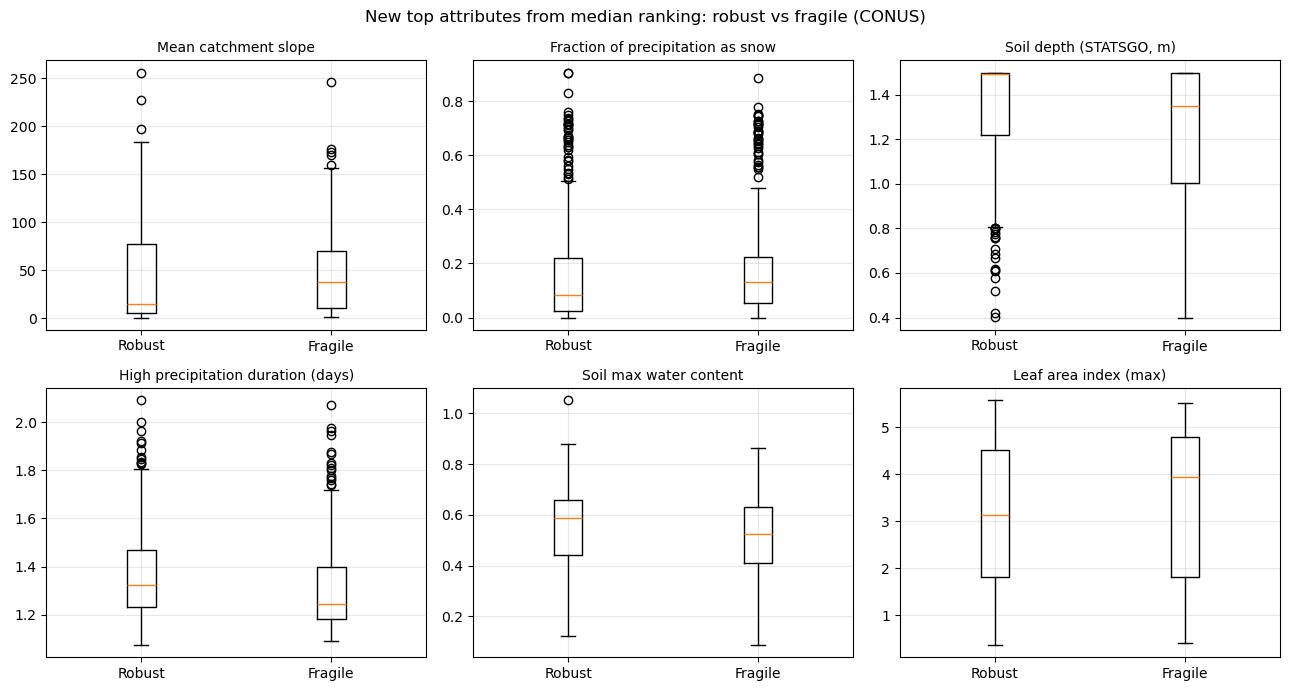

Saved: robust_vs_fragile_boxplots_new_attrs_CONUS.png


In [10]:
# Step 5d: boxplots for new top attributes from the median-based ranking

# Top attributes from the median ranking (excluding ones we already plotted)
new_top_attrs = [
    "slope_mean",
    "frac_snow",
    "soil_depth_statsgo",
    "high_prec_dur",
    "max_water_content",
    "lai_max",
]

# Plain English labels
attr_labels_new = {
    "slope_mean":         "Mean catchment slope",
    "frac_snow":          "Fraction of precipitation as snow",
    "soil_depth_statsgo": "Soil depth (STATSGO, m)",
    "high_prec_dur":      "High precipitation duration (days)",
    "max_water_content":  "Soil max water content",
    "lai_max":            "Leaf area index (max)",
}

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes = axes.flatten()

for i, col in enumerate(new_top_attrs):
    rob_vals = data.loc[data["is_robust"], col].dropna()
    frg_vals = data.loc[~data["is_robust"], col].dropna()
    
    axes[i].boxplot([rob_vals, frg_vals], labels=["Robust", "Fragile"])
    label = attr_labels_new.get(col, col)
    axes[i].set_title(label, fontsize=10)
    axes[i].grid(True, alpha=0.3)

plt.suptitle("New top attributes from median ranking: robust vs fragile (CONUS)", fontsize=12)
plt.tight_layout()

fig_file = OUT_PDF / "robust_vs_fragile_boxplots_new_attrs_CONUS.png"
plt.savefig(fig_file, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", fig_file.name)

### What the boxplots show for the new attributes

After checking the boxplots, only some of the new top attributes from the median ranking actually show a real separation between robust and fragile basins.

**Real but moderate findings:**
- **Leaf area index (max)**: fragile basins have higher summer vegetation cover (median 3.9 vs 3.1 in robust). This fits with the vegetation seasonality story — denser summer vegetation means stronger seasonal cycles.
- **Soil max water content**: robust basins have slightly higher water-holding capacity (median 0.58 vs 0.52). The difference is small but visible in the boxplot.

**Weak findings (small shifts, lots of overlap):**
- **Mean catchment slope**: fragile basins are steeper on average (median 37 vs 14), but the two groups overlap heavily. Not a strong separator on its own.
- **Fraction of snow**: fragile basins have slightly more snow (median 0.13 vs 0.08), but most basins in both groups have very little snow. The difference is small.

**Findings that did not hold up:**
- **Soil depth (STATSGO)**: this attribute appears to be capped at 1.5 m in the data, so it cannot really separate deeper-soil basins from shallower ones. I am dropping this from the story.
- **High precipitation duration**: the medians of the two groups are almost the same. No real difference. Dropping this too.

**Overall:**

After going through two rankings and two rounds of boxplot checks, the clearest and most consistent finding is that **vegetation seasonality (gvf_diff and lai_diff)** separates robust from fragile basins across all 671 basins. Slope, snow fraction, summer LAI, and soil water content all point in the same direction but with weaker and less consistent effects.

Soil depth, soil conductivity, sand fraction, and longitude looked important in the mean-based ranking but did not survive the boxplot check. I am not including them in the final story.

So the main takeaway is one clear finding supported by several weaker ones — not a long list of equally important attributes.

## Step 6 — Attribute comparison within the Northeast only

In Step 5, I compared robust and fragile basins across all 671 basins and found that vegetation seasonality (gvf_diff) was the strongest separator, with slope, snow fraction, summer LAI, and soil water content showing weaker supporting effects.

Now I repeat the same comparison but using only the 147 Northeast basins (HUC 01, 02, 05). The reason is that the CONUS finding might be a regional effect — the Northeast as a whole has high vegetation seasonality and also happens to have many fragile basins. But does vegetation seasonality actually separate robust from fragile basins within the Northeast itself, where almost every basin has high seasonality anyway?

If gvf_diff still comes out on top within the Northeast, the CONUS story holds. If it drops down the ranking, it means the CONUS finding was mostly a between-region pattern (Northeast vs the rest of the country) rather than something that explains within-region differences.

One thing to keep in mind: there are only 45 robust and 102 fragile basins in the Northeast, which is a much smaller sample than the full 671. So the results here will be a bit noisier and I will be more careful about what I claim.

In [11]:
# Step 6: robust vs fragile attribute comparison, Northeast basins only

# 1) Filter to Northeast basins
ne_data = data[data["huc_02"].astype(str).str.zfill(2).isin(["01", "02", "05"])].copy()

n_ne_robust = int(ne_data["is_robust"].sum())
n_ne_fragile = int((~ne_data["is_robust"]).sum())
print("Northeast basins total :", len(ne_data))
print("Robust                 :", n_ne_robust)
print("Fragile                :", n_ne_fragile)

# 2) Mean-based effect size (Cohen's d) for Northeast
rows_ne_mean = []
for col in numeric_cols:
    rob_vals = ne_data.loc[ne_data["is_robust"], col].dropna()
    frg_vals = ne_data.loc[~ne_data["is_robust"], col].dropna()
    
    if len(rob_vals) < 5 or len(frg_vals) < 10:
        continue
    
    mean_rob = rob_vals.mean()
    mean_frg = frg_vals.mean()
    diff = mean_rob - mean_frg
    pooled_std = np.sqrt((rob_vals.var() + frg_vals.var()) / 2)
    
    if pooled_std == 0 or np.isnan(pooled_std):
        effect = np.nan
    else:
        effect = diff / pooled_std
    
    rows_ne_mean.append({
        "attribute": col,
        "mean_robust": mean_rob,
        "mean_fragile": mean_frg,
        "diff": diff,
        "effect_size": effect,
        "abs_effect": abs(effect),
    })

ne_compare_mean = pd.DataFrame(rows_ne_mean).sort_values("abs_effect", ascending=False)

# 3) Median-based effect size for Northeast
rows_ne_median = []
for col in numeric_cols:
    rob_vals = ne_data.loc[ne_data["is_robust"], col].dropna()
    frg_vals = ne_data.loc[~ne_data["is_robust"], col].dropna()
    
    if len(rob_vals) < 5 or len(frg_vals) < 10:
        continue
    
    median_rob = rob_vals.median()
    median_frg = frg_vals.median()
    diff_median = median_rob - median_frg
    iqr_rob = rob_vals.quantile(0.75) - rob_vals.quantile(0.25)
    iqr_frg = frg_vals.quantile(0.75) - frg_vals.quantile(0.25)
    pooled_iqr = (iqr_rob + iqr_frg) / 2
    
    if pooled_iqr == 0 or np.isnan(pooled_iqr):
        median_effect = np.nan
    else:
        median_effect = diff_median / pooled_iqr
    
    rows_ne_median.append({
        "attribute": col,
        "median_robust": median_rob,
        "median_fragile": median_frg,
        "diff_median": diff_median,
        "median_effect": median_effect,
        "abs_median_effect": abs(median_effect),
    })

ne_compare_median = pd.DataFrame(rows_ne_median).sort_values("abs_median_effect", ascending=False)

# 4) Save both rankings
ne_compare_mean.to_csv(OUT_SUMMARY / "attr_compare_robust_vs_fragile_NE_mean.csv", index=False)
ne_compare_median.to_csv(OUT_SUMMARY / "attr_compare_robust_vs_fragile_NE_median.csv", index=False)

print("\nSaved both ranking CSVs in outputs/summary_csv")

# 5) Show top 15 by mean and by median
print("\n--- Top 15 by mean-based effect (Northeast only) ---")
print(ne_compare_mean[["attribute", "mean_robust", "mean_fragile",
                      "diff", "effect_size"]].head(15).round(3).to_string(index=False))

print("\n--- Top 15 by median-based effect (Northeast only) ---")
print(ne_compare_median[["attribute", "median_robust", "median_fragile",
                        "diff_median", "median_effect"]].head(15).round(3).to_string(index=False))

# 6) Quick check: how does gvf_diff rank in both?
print("\n--- Where does gvf_diff rank in the Northeast comparison? ---")
mean_rank = ne_compare_mean["attribute"].tolist().index("gvf_diff") + 1 if "gvf_diff" in ne_compare_mean["attribute"].values else None
median_rank = ne_compare_median["attribute"].tolist().index("gvf_diff") + 1 if "gvf_diff" in ne_compare_median["attribute"].values else None

print(f"gvf_diff rank by mean   : {mean_rank}")
print(f"gvf_diff rank by median : {median_rank}")

if "gvf_diff" in ne_compare_median["attribute"].values:
    row = ne_compare_median[ne_compare_median["attribute"] == "gvf_diff"].iloc[0]
    print(f"  gvf_diff median (robust): {row['median_robust']:.3f}")
    print(f"  gvf_diff median (fragile): {row['median_fragile']:.3f}")
    print(f"  Median effect size      : {row['median_effect']:.3f}")

Northeast basins total : 147
Robust                 : 45
Fragile                : 102

Saved both ranking CSVs in outputs/summary_csv

--- Top 15 by mean-based effect (Northeast only) ---
           attribute  mean_robust  mean_fragile     diff  effect_size
          slope_mean       21.098        42.073  -20.975       -0.993
soil_depth_pelletier       17.989         3.639   14.350        0.961
           elev_mean      292.073       497.360 -205.287       -0.816
       high_prec_dur        1.209         1.173    0.035        0.712
           silt_frac       37.199        44.889   -7.690       -0.692
        low_prec_dur        3.951         3.605    0.346        0.663
  soil_depth_statsgo        1.356         1.214    0.143        0.613
            gvf_diff        0.438         0.480   -0.042       -0.593
       soil_porosity        0.437         0.449   -0.011       -0.591
   soil_conductivity        1.981         1.370    0.610        0.590
          other_frac        6.132         

### Checking the top Northeast attributes with boxplots

The median-based ranking for the Northeast pointed to elevation, slope, and snow fraction as the strongest separators. Before I include these in my interpretation, I check the boxplots to make sure the separation is real and not being driven by a few unusual basins. I learned from the earlier steps that a high ranking does not always mean a clean separation, so I always check visually before trusting the numbers.

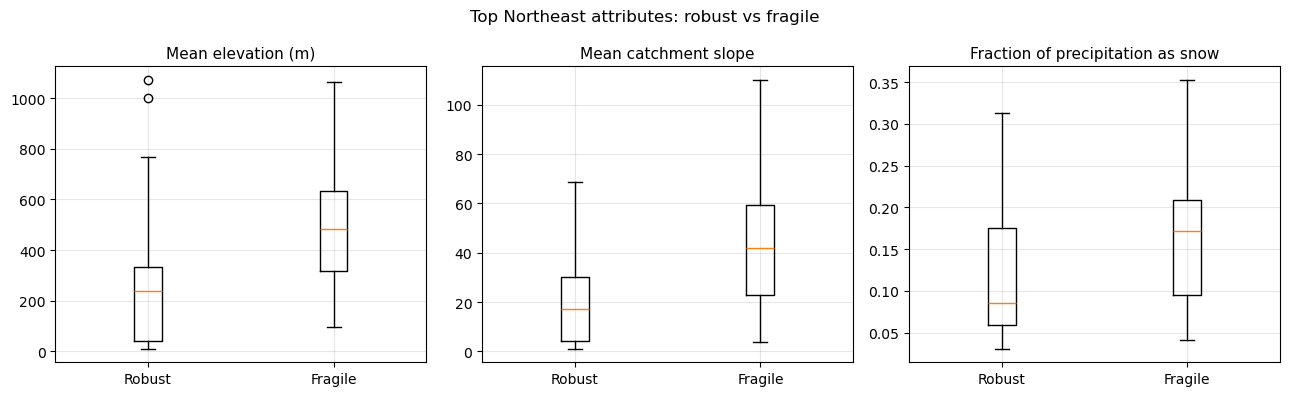

Saved: robust_vs_fragile_boxplots_NE.png


In [12]:
# Step 6b: boxplots for the top Northeast attributes

ne_top_attrs = ["elev_mean", "slope_mean", "frac_snow"]

attr_labels_ne = {
    "elev_mean":  "Mean elevation (m)",
    "slope_mean": "Mean catchment slope",
    "frac_snow":  "Fraction of precipitation as snow",
}

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for i, col in enumerate(ne_top_attrs):
    rob_vals = ne_data.loc[ne_data["is_robust"], col].dropna()
    frg_vals = ne_data.loc[~ne_data["is_robust"], col].dropna()
    
    axes[i].boxplot([rob_vals, frg_vals], labels=["Robust", "Fragile"])
    label = attr_labels_ne.get(col, col)
    axes[i].set_title(label, fontsize=11)
    axes[i].grid(True, alpha=0.3)

plt.suptitle("Top Northeast attributes: robust vs fragile", fontsize=12)
plt.tight_layout()

fig_file = OUT_PDF / "robust_vs_fragile_boxplots_NE.png"
plt.savefig(fig_file, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", fig_file.name)

### Checking the two long-lag Tair basins from my earlier work

In an earlier notebook, I looked at two basins where Tair was the dominant forcing at unusually long lags — basin 03159540 with a peak lag of 21 days and basin 06353000 with a peak lag of 23 days. At that time I treated them as examples of a real long-lag Tair signal.

Now that I have found elevation, slope, and snow fraction are the key attributes separating robust from fragile basins in the Northeast, I want to check whether these two basins actually fit that pattern. If they do — high elevation, steep slope, high snow fraction — then the long-lag Tair signal might be explained by snowmelt timing. If they do not fit the pattern, something else is going on and I need to reconsider the earlier interpretation.

I look up their robustness flag, dominant forcing, peak lag, and the key attributes found in this step.

In [13]:
# Step 6c: lookup for the two long-lag Tair basins from earlier work

basins_to_check = ["03159540", "06353000"]

# Build a small lookup table
lookup = data[data["gauge_id"].isin(basins_to_check)][[
    "gauge_id", "huc_02",
    "dominant_forcing", "margin", "is_robust",
    "elev_mean", "slope_mean", "frac_snow",
    "p_mean", "pet_mean", "aridity",
    "frac_forest", "lai_diff",
    "soil_depth_pelletier", "soil_depth_statsgo",
    "geol_permeability", "runoff_ratio", "baseflow_index",
]]

# Add the dominant_lag separately from the robust table
lookup = lookup.merge(
    robust[["gauge_id", "dominant_lag"]],
    on="gauge_id", how="left"
)

# Add basin name for context
lookup = lookup.merge(
    basin_meta[["gauge_id", "gauge_name", "gauge_lat", "gauge_lon"]],
    on="gauge_id", how="left"
)

# Reorder columns for readable printout
cols_order = [
    "gauge_id", "gauge_name", "huc_02", "gauge_lat", "gauge_lon",
    "dominant_forcing", "dominant_lag", "margin", "is_robust",
    "elev_mean", "slope_mean", "frac_snow",
    "p_mean", "pet_mean", "aridity", "frac_forest", "lai_diff",
    "soil_depth_pelletier", "soil_depth_statsgo",
    "geol_permeability", "runoff_ratio", "baseflow_index",
]
lookup = lookup[[c for c in cols_order if c in lookup.columns]]

# Print transposed for readability
print("Long-lag Tair basins from earlier work:\n")
print(lookup.T.to_string())

# Compare each basin's elev/slope/snow against the Northeast medians
print("\n\n--- How do these basins compare against Northeast medians ---\n")
ne_robust_med = ne_data[ne_data["is_robust"]][["elev_mean", "slope_mean", "frac_snow"]].median()
ne_fragile_med = ne_data[~ne_data["is_robust"]][["elev_mean", "slope_mean", "frac_snow"]].median()

compare = pd.DataFrame({
    "robust_median (NE)":  ne_robust_med,
    "fragile_median (NE)": ne_fragile_med,
})

for gid in basins_to_check:
    row = lookup[lookup["gauge_id"] == gid][["elev_mean", "slope_mean", "frac_snow"]].T
    row.columns = [gid]
    compare = compare.join(row, how="left")

print(compare.round(3).to_string())

Long-lag Tair basins from earlier work:

                                                0                           1
gauge_id                                 03159540                    06353000
gauge_name            Shade River near Chester OH  CEDAR CREEK NR RALEIGH, ND
huc_02                                          5                          10
gauge_lat                                39.06369                    46.09167
gauge_lon                                -81.8818                  -101.33374
dominant_forcing                             Tair                        Tair
dominant_lag                                   21                          23
margin                                   0.138804                    0.151225
is_robust                                   False                       False
elev_mean                                   232.8                      767.71
slope_mean                               10.08158                     9.54494
frac_snow              

### What I found — Northeast comparison

Comparing robust and fragile basins within the Northeast (147 basins total: 45 robust, 102 fragile) gives a different story than the CONUS-wide comparison.

**What separates robust from fragile within the Northeast:**

The strongest separators are elevation, slope, and snow fraction, and all three are confirmed by the boxplots:

- Robust basins: median elevation 240 m, median slope 17, median snow fraction 0.085 — generally lowland basins with gentle terrain and little snow.
- Fragile basins: median elevation 484 m, median slope 42, median snow fraction 0.17 — generally upland Appalachian basins with steep terrain and partial snow cover.

**Vegetation seasonality (gvf_diff) is not a strong separator within the Northeast** — it ranked 24th by median effect size (0.33). The CONUS-wide finding that gvf_diff was the top separator was mostly a between-region effect. The Northeast has high seasonality and also happens to have many fragile basins, but within the Northeast itself, seasonality does not tell robust from fragile apart.

So inside the Northeast, the story is about topography and snow, not vegetation.

**Why this makes physical sense:**

Lowland Northeast basins have warmer winters, less snow, and gentle slopes. Streamflow there responds fairly directly to rainfall, so PRCP stands out clearly as the dominant forcing. Upland Appalachian basins have colder winters with snow, steep terrain, and slower storage. Temperature controls when snow melts, and ET also plays a role, so PRCP, SRAD, Tair, and VP all end up carrying similar information about Q. The dominant forcing label becomes fragile.

**What I found about the two long-lag Tair basins from earlier:**

I checked the two basins I investigated earlier as long-lag Tair examples — 03159540 and 06353000. They do not both fit the upland-snow pattern I expected.

- Basin 03159540 (Shade River, OH) is fragile with a peak lag of 21 days. Its elevation (233 m), slope (10), and snow fraction (0.08) actually match the robust pattern, not the upland Appalachian pattern. But it has very high vegetation seasonality (lai_diff 4.2) and is 82% forested. The long Tair lag here is more likely explained by seasonal ET cycling in a humid forest, not by snowmelt.

- Basin 06353000 (Cedar Creek, ND) is in HUC 10 — it is a North Dakota Plains basin, not part of the Northeast at all. It is semi-arid with a runoff ratio of only 0.037, meaning just 3.7% of rainfall becomes streamflow. With such weak streamflow, TE estimates are noisy and the "Tair-dominant at lag 23" label (margin 0.15) is likely unreliable.

So the long-lag Tair signal in my earlier work is not one single phenomenon. At least two different situations can produce it: a humid, densely forested basin with strong seasonal ET cycles (03159540), and a semi-arid basin with very weak streamflow where TE estimates are not reliable (06353000).

**A few caveats:**

- The Northeast sample is small (45 robust, 102 fragile), so results here are less certain than the full CONUS comparison.
- Elevation, slope, and snow fraction are correlated with each other — upland basins tend to be steep and snowy at the same time. So it is hard to say which one matters most on its own. I treat them together as one combined topographic-snow pattern.
- The CONUS gvf_diff finding from Step 5 is not wrong. It explains why the Northeast as a whole is more fragile than the rest of the country. But it does not explain why some Northeast basins are fragile and others are robust within the region. That within-region question is answered by elevation, slope, and snow.